<a href="https://colab.research.google.com/github/belinatom/NALAPROJECT/blob/main/nlp_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 1 : STATIC EMBEDDINGS
### TF-IDF , WORD2VEC , FASTTEXT AND NEURAL NETWORK
This notebook responds to task one of the project - In this I apply static embeddings methods and combine them with neural networks to classify proverbs. Different methods are used with the following considerations
1. TF-IDF and Word2Vec - As required in the assignment
2. Fasttext - A swahili pretrained version to see if there is better performance with swahili context embeddings
3. Char N-grams - Swahili is an agglutinative language - characters in a word make context e.g si can mean negation and first person reference and so forth therefore the expectation is to see better performance with char N-grams.

In [2]:
# Installing packages for the task - only running once in the beginning
# !pip install -q gdown wandb mlflow fasttext
# !pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 5.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 6.5 MB/s eta 

In [3]:
## PACKAGES IMPORTS
import os, re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from getpass import getpass
import wandb, mlflow

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, classification_report

from gensim.models import Word2Vec
import fasttext
import fasttext.util
import gdown

seed = 42
np.random.seed(seed); random.seed(seed); torch.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_style('whitegrid')
print(f'✓ Imports loaded | Device: {device}')


✓ Imports loaded | Device: cpu


In [4]:
# Downloading dataset from Google Drive
FILE_ID = '1Rp9Fg1BitlAR3d1JyH4DmTp3aSKr8H1t'
gdown.download(
    f'https://drive.google.com/uc?id={FILE_ID}',
    '/content/swahiliproverbs.csv',
    quiet=False, fuzzy=True
)

df = pd.read_csv('/content/swahiliproverbs.csv')
df = df[['swahili_proverb', 'label']].dropna().copy()
df['swahili_proverb'] = df['swahili_proverb'].astype(str).str.strip()
df['label']           = df['label'].astype(str).str.strip()
df = df[df['swahili_proverb'] != ''].reset_index(drop=True)

text_col, label_col = 'swahili_proverb', 'label'
print(f'✓ Loaded: {len(df)} proverbs, {df[label_col].nunique()} categories')
df.head(3)


Downloading...
From: https://drive.google.com/uc?id=1Rp9Fg1BitlAR3d1JyH4DmTp3aSKr8H1t
To: /content/swahiliproverbs.csv
100%|██████████| 290k/290k [00:00<00:00, 24.3MB/s]


✓ Loaded: 5060 proverbs, 56 categories


,swahili_proverb,label
0,Achekaye kilema hata kwao kipo.,Abuse
1,Afadhali lawama ya wazi.,Abuse
2,Afanyae mzaha na watu humlazimu awe na saburi.,Abuse


In [5]:
# Encoding labels
le = LabelEncoder()
y = le.fit_transform(df[label_col])
x_text = df[text_col].tolist()
num_classes = len(le.classes_)


# Splitting data to train-test-validation
x_train, x_test, y_train, y_test = train_test_split(
    x_text, y, test_size=0.2, random_state=seed, stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=seed, stratify=y_train
)
print(f'✓ Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)} | Classes: {num_classes}')


✓ Train: 3643 | Val: 405 | Test: 1012 | Classes: 56


In [6]:
# MLP classifier (2 linear layers + ReLU in between) and training function
class SimpleMLP(nn.Module):
    """Two linear layers with a ReLU activation in between."""
    def __init__(self, input_size, hidden_size=128, num_classes=None):
        super().__init__()
        self.fc1  = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2  = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


def train_and_evaluate(x_tr, y_tr, x_vl, y_vl, x_te, y_te, tag,
                       input_size, num_classes, epochs=50):
    def to_t(x):
        arr = x.toarray() if hasattr(x, 'toarray') else x
        return torch.FloatTensor(arr).to(device)

    tr_loader = DataLoader(TensorDataset(to_t(x_tr), torch.LongTensor(y_tr).to(device)),
                           batch_size=32, shuffle=True)
    vl_loader = DataLoader(TensorDataset(to_t(x_vl), torch.LongTensor(y_vl).to(device)),
                           batch_size=32)
    te_loader = DataLoader(TensorDataset(to_t(x_te), torch.LongTensor(y_te).to(device)),
                           batch_size=32)

    model     = SimpleMLP(input_size, 128, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc, best_val_f1 = 0, 0
    history = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0, 0
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item(); n_batches += 1
        train_loss = epoch_loss / n_batches

        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for bx, by in vl_loader:
                preds.extend(torch.max(model(bx), 1)[1].cpu().numpy())
                targets.extend(by.cpu().numpy())

        val_acc = accuracy_score(targets, preds)
        val_f1  = f1_score(targets, preds, average='macro', zero_division=0)

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_acc, best_val_f1 = val_acc, val_f1
            torch.save(model.state_dict(), f'/tmp/best_{tag}.pth')

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{epochs} | Loss={train_loss:.4f} | Val Acc={val_acc:.4f} F1={val_f1:.4f}')

    model.load_state_dict(torch.load(f'/tmp/best_{tag}.pth'))
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for bx, by in te_loader:
            preds.extend(torch.max(model(bx), 1)[1].cpu().numpy())
            targets.extend(by.cpu().numpy())

    test_acc = accuracy_score(targets, preds)
    test_f1  = f1_score(targets, preds, average='macro', zero_division=0)
    test_mcc = matthews_corrcoef(targets, preds)

    print(f'\n✓ {tag} | Val Macro-F1={best_val_f1:.4f}')
    print(f'✓ {tag} | Test Acc={test_acc:.4f} | Macro-F1={test_f1:.4f} | MCC={test_mcc:.4f}')
    print(f'\nPer-class report ({tag}):\n')
    print(classification_report(targets, preds, zero_division=0))

    return {'tag': tag, 'val_acc': best_val_acc, 'val_f1': best_val_f1,
            'test_acc': test_acc, 'test_f1': test_f1, 'test_mcc': test_mcc,
            'history': history, 'model_path': f'/tmp/best_{tag}.pth'}

print('✓ Model and training function defined')


✓ Model and training function defined


In [7]:
# Cell 5 — TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=1000)
x_tr_tfidf = normalize(tfidf.fit_transform(x_train))
x_vl_tfidf = normalize(tfidf.transform(x_val))
x_te_tfidf = normalize(tfidf.transform(x_test))
print(f'✓ TF-IDF features: {x_tr_tfidf.shape}')

result_tfidf = train_and_evaluate(
    x_tr_tfidf, y_train, x_vl_tfidf, y_val, x_te_tfidf, y_test,
    tag='TFIDF', input_size=x_tr_tfidf.shape[1], num_classes=num_classes, epochs=50
)


✓ TF-IDF features: (3643, 1000)
  Epoch 10/50 | Loss=2.0294 | Val Acc=0.2444 F1=0.1940
  Epoch 20/50 | Loss=1.0468 | Val Acc=0.2247 F1=0.1858
  Epoch 30/50 | Loss=0.7399 | Val Acc=0.2049 F1=0.1725
  Epoch 40/50 | Loss=0.6108 | Val Acc=0.2074 F1=0.1774
  Epoch 50/50 | Loss=0.5439 | Val Acc=0.1975 F1=0.1744

✓ TFIDF | Val Macro-F1=0.1973
✓ TFIDF | Test Acc=0.2134 | Macro-F1=0.2127 | MCC=0.1928

Per-class report (TFIDF):

              precision    recall  f1-score   support

           0       0.20      0.13      0.16        30
           1       0.08      0.20      0.12        50
           2       0.14      0.22      0.17        23
           3       0.36      0.50      0.42         8
           4       0.22      0.29      0.25        14
           5       0.04      0.05      0.04        39
           6       0.50      0.30      0.38        10
           7       0.00      0.00      0.00        18
           8       0.08      0.07      0.08        27
           9       0.00      0.00   

In [8]:
# CHARACTER N-GRAM TF-IDF
char_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,6), min_df=2, max_features=2000)
x_tr_char = normalize(char_tfidf.fit_transform(x_train))
x_vl_char = normalize(char_tfidf.transform(x_val))
x_te_char = normalize(char_tfidf.transform(x_test))
print(f'✓ Char N-gram features: {x_tr_char.shape}')

result_char = train_and_evaluate(
    x_tr_char, y_train, x_vl_char, y_val, x_te_char, y_test,
    tag='CharNgram', input_size=x_tr_char.shape[1], num_classes=num_classes, epochs=50
)


✓ Char N-gram features: (3643, 2000)
  Epoch 10/50 | Loss=1.6733 | Val Acc=0.2617 F1=0.2032
  Epoch 20/50 | Loss=0.4930 | Val Acc=0.2494 F1=0.2205
  Epoch 30/50 | Loss=0.1443 | Val Acc=0.2395 F1=0.2147
  Epoch 40/50 | Loss=0.0567 | Val Acc=0.2420 F1=0.2158
  Epoch 50/50 | Loss=0.0274 | Val Acc=0.2420 F1=0.2146

✓ CharNgram | Val Macro-F1=0.2254
✓ CharNgram | Test Acc=0.2312 | Macro-F1=0.2246 | MCC=0.2113

Per-class report (CharNgram):

              precision    recall  f1-score   support

           0       0.16      0.27      0.20        30
           1       0.14      0.24      0.18        50
           2       0.16      0.17      0.17        23
           3       0.25      0.25      0.25         8
           4       0.25      0.29      0.27        14
           5       0.09      0.10      0.09        39
           6       0.29      0.20      0.24        10
           7       0.08      0.06      0.06        18
           8       0.11      0.11      0.11        27
           9       

In [9]:
# Word2Vec - 1 EPOCH VS. 10 EPOCHS
def tokenize(texts):
    return [re.findall(r'\b\w+\b', t.lower()) for t in texts]

tokens_train = tokenize(x_train)
tokens_val   = tokenize(x_val)
tokens_test  = tokenize(x_test)

def doc_vec(tokens, model, dim=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

def embed_corpus(token_lists, model):
    return np.array([doc_vec(t, model) for t in token_lists])

# Word2Vec — 1 epoch
w2v_1 = Word2Vec(sentences=tokens_train, vector_size=100, window=5,
                 min_count=2, sg=1, epochs=1, seed=seed, workers=1)
result_w2v1 = train_and_evaluate(
    embed_corpus(tokens_train, w2v_1), y_train,
    embed_corpus(tokens_val,   w2v_1), y_val,
    embed_corpus(tokens_test,  w2v_1), y_test,
    tag='Word2Vec-1ep', input_size=100, num_classes=num_classes, epochs=50
)

# Word2Vec — 10 epochs
w2v_10 = Word2Vec(sentences=tokens_train, vector_size=100, window=5,
                  min_count=2, sg=1, epochs=10, seed=seed, workers=1)
result_w2v10 = train_and_evaluate(
    embed_corpus(tokens_train, w2v_10), y_train,
    embed_corpus(tokens_val,   w2v_10), y_val,
    embed_corpus(tokens_test,  w2v_10), y_test,
    tag='Word2Vec-10ep', input_size=100, num_classes=num_classes, epochs=50
)


  Epoch 10/50 | Loss=3.8792 | Val Acc=0.0494 F1=0.0017
  Epoch 20/50 | Loss=3.8514 | Val Acc=0.0691 F1=0.0116
  Epoch 30/50 | Loss=3.8170 | Val Acc=0.0667 F1=0.0083
  Epoch 40/50 | Loss=3.7844 | Val Acc=0.0716 F1=0.0104
  Epoch 50/50 | Loss=3.7458 | Val Acc=0.0741 F1=0.0125

✓ Word2Vec-1ep | Val Macro-F1=0.0136
✓ Word2Vec-1ep | Test Acc=0.0573 | Macro-F1=0.0092 | MCC=0.0617

Per-class report (Word2Vec-1ep):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.05      1.00      0.09        50
           2       0.00      0.00      0.00        23
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00        14
           5       0.00      0.00      0.00        39
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00        18
           8       0.00      0.00      0.00        27
           9       0.00      0.00      0.00    

In [10]:
# Cell 8 — FastText (Facebook pre-trained Swahili cc.sw.300 embeddings)
print('Downloading Facebook Swahili FastText model (cc.sw.300.bin)...')
fasttext.util.download_model('sw', if_exists='ignore')
ft = fasttext.load_model('cc.sw.300.bin')
print('✓ Model loaded')

def doc_vec_ft(tokens, model, dim=300):
    vecs = [model.get_word_vector(w) for w in tokens if w.strip()]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

x_tr_ft = np.array([doc_vec_ft(t, ft) for t in tokens_train])
x_vl_ft = np.array([doc_vec_ft(t, ft) for t in tokens_val])
x_te_ft = np.array([doc_vec_ft(t, ft) for t in tokens_test])

result_ft = train_and_evaluate(
    x_tr_ft, y_train, x_vl_ft, y_val, x_te_ft, y_test,
    tag='FastText', input_size=300, num_classes=num_classes, epochs=50
)



✓ Model loaded
  Epoch 10/50 | Loss=3.3806 | Val Acc=0.1827 F1=0.0667
  Epoch 20/50 | Loss=2.9256 | Val Acc=0.1951 F1=0.1360
  Epoch 30/50 | Loss=2.6146 | Val Acc=0.2173 F1=0.1722
  Epoch 40/50 | Loss=2.3841 | Val Acc=0.2173 F1=0.1932
  Epoch 50/50 | Loss=2.1977 | Val Acc=0.2346 F1=0.2001

✓ FastText | Val Macro-F1=0.2095
✓ FastText | Test Acc=0.2273 | Macro-F1=0.1972 | MCC=0.2059

Per-class report (FastText):

              precision    recall  f1-score   support

           0       0.09      0.10      0.09        30
           1       0.08      0.16      0.11        50
           2       0.09      0.04      0.06        23
           3       0.44      0.50      0.47         8
           4       0.33      0.29      0.31        14
           5       0.07      0.10      0.09        39
           6       0.60      0.30      0.40        10
           7       0.29      0.11      0.16        18
           8       0.00      0.00      0.00        27
           9       0.14      0.14      0.14


TASK 1 — FINAL RESULTS
          tag  val_acc   val_f1  test_acc  test_f1  test_mcc
        TFIDF 0.224691 0.197276  0.213439 0.212746  0.192834
    CharNgram 0.259259 0.225418  0.231225 0.224630  0.211347
 Word2Vec-1ep 0.064198 0.013610  0.057312 0.009215  0.061651
Word2Vec-10ep 0.059259 0.011385  0.052372 0.004744  0.013593
     FastText 0.244444 0.209534  0.227273 0.197245  0.205938


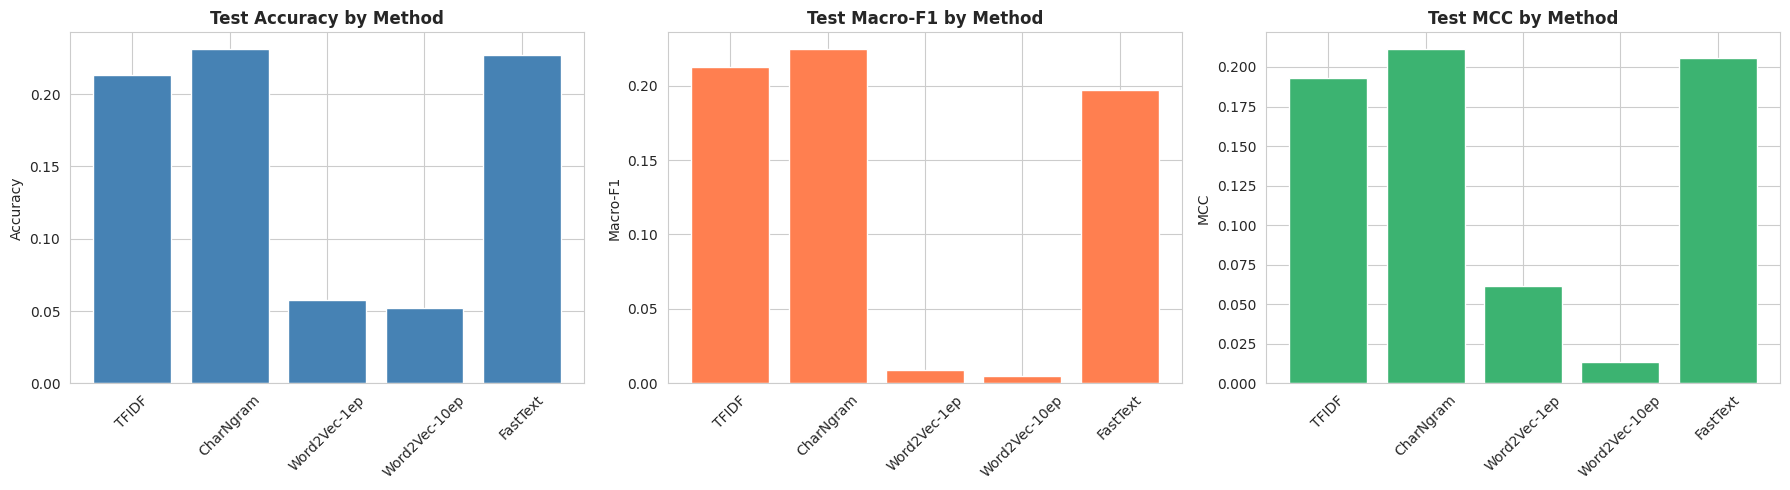

In [11]:
# Cell 9 — Results summary and visualization
all_results = [result_tfidf, result_char, result_w2v1, result_w2v10, result_ft]

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('history', 'model_path')}
    for r in all_results
])[['tag', 'val_acc', 'val_f1', 'test_acc', 'test_f1', 'test_mcc']]

print('\n' + '='*60)
print('TASK 1 — FINAL RESULTS')
print('='*60)
print(results_df.to_string(index=False))

results_df.to_csv('/content/task1_results.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(results_df['tag'], results_df['test_acc'], color='steelblue')
axes[0].set_title('Test Accuracy by Method', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(results_df['tag'], results_df['test_f1'], color='coral')
axes[1].set_title('Test Macro-F1 by Method', fontweight='bold')
axes[1].set_ylabel('Macro-F1'); axes[1].tick_params(axis='x', rotation=45)
axes[2].bar(results_df['tag'], results_df['test_mcc'], color='mediumseagreen')
axes[2].set_title('Test MCC by Method', fontweight='bold')
axes[2].set_ylabel('MCC'); axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/content/task1_results.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Experiment Tracking — Logged at the End

The next cell logs all metrics, models, and artifacts to:
- **Weights & Biases**
- **MLflow**


In [13]:
# Cell 10 — Log everything to W&B and MLflow


CONFIG = {
    'task': 'Task 1',
    'optimizer': 'Adam', 'lr': 0.001, 'batch_size': 32,
    'hidden_size': 128, 'epochs': 50, 'num_classes': num_classes,
    'train_size': len(x_train), 'val_size': len(x_val), 'test_size': len(x_test)
}

# ── Setup ────────────────────────────────────────────────────
os.makedirs('/content/mlruns', exist_ok=True)
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('file:///content/mlruns')

wandb_key = getpass('Paste W&B API key (wandb.ai/authorize): ')
wandb.login(key=wandb_key)

# ── 1. Weights & Biases ──────────────────────────────────────
wandb.init(project='nalapro-swahili', name='task1-static-embeddings',
           config=CONFIG, reinit=True)
for res in all_results:
    h = res['history']
    for i, ep in enumerate(h['epoch']):
        wandb.log({
            f"{res['tag']}/train_loss": h['train_loss'][i],
            f"{res['tag']}/val_acc":    h['val_acc'][i],
            f"{res['tag']}/val_f1":     h['val_f1'][i],
            'epoch': ep
        })
    wandb.log({
        f"{res['tag']}/test_acc":     res['test_acc'],
        f"{res['tag']}/test_f1":      res['test_f1'],
        f"{res['tag']}/test_mcc":      res['test_mcc'],
        f"{res['tag']}/best_val_acc": res['val_acc'],
        f"{res['tag']}/best_val_f1":  res['val_f1']
    })
    art = wandb.Artifact(f"model-{res['tag']}", type='model')
    art.add_file(res['model_path']); wandb.log_artifact(art)

wandb.log({'task1_summary': wandb.Table(dataframe=results_df)})
wandb.log({'task1_chart':   wandb.Image('/content/task1_results.png')})
wandb_url = wandb.run.url
wandb.finish()

# ── 3. MLflow ────────────────────────────────────────────────
mlflow.set_experiment('nalapro-task1-static')
for res in all_results:
    with mlflow.start_run(run_name=f"task1-{res['tag']}"):
        mlflow.log_params({**CONFIG, 'method': res['tag']})
        h = res['history']
        for i, ep in enumerate(h['epoch']):
            mlflow.log_metric('train_loss', h['train_loss'][i], step=ep)
            mlflow.log_metric('val_acc',    h['val_acc'][i],    step=ep)
            mlflow.log_metric('val_f1',     h['val_f1'][i],     step=ep)
        mlflow.log_metric('test_acc',     res['test_acc'])
        mlflow.log_metric('test_f1',      res['test_f1'])
        mlflow.log_metric('test_mcc',     res['test_mcc'])
        mlflow.log_metric('best_val_acc', res['val_acc'])
        mlflow.log_metric('best_val_f1',  res['val_f1'])
        mlflow.log_artifact(res['model_path'])

with mlflow.start_run(run_name='task1-summary'):
    mlflow.log_artifact('/content/task1_results.csv')
    mlflow.log_artifact('/content/task1_results.png')

print('\n' + '='*60)
print('✓ ALL TRACKING COMPLETE')
print('='*60)
print(f'W&B:    {wandb_url}')
print('MLflow: Run  !mlflow ui --backend-store-uri /content/mlruns')


Paste W&B API key (wandb.ai/authorize): ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


wandb: WARNING Artifact "model-TFIDF" already exists with the same content. No new version will be created.


CharNgram/best_val_acc,▁
CharNgram/best_val_f1,▁
CharNgram/test_acc,▁
CharNgram/test_f1,▁
CharNgram/test_mcc,▁
CharNgram/train_loss,██▇▇▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CharNgram/val_acc,▁▄▅▆▆▇▇███▇███▇█▇▇██▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
CharNgram/val_f1,▁▄▄▅▆▇▇▇█████████████▇█▇████████████████
FastText/best_val_acc,▁
FastText/best_val_f1,▁
+31,...



✓ ALL TRACKING COMPLETE
W&B:    https://wandb.ai/belinda-mziray-hochschule-luzern/nalapro-swahili/runs/sruwxq9n
MLflow: Run  !mlflow ui --backend-store-uri /content/mlruns
